## EDA Operation 1 — Summary Statistics
Loads the dataset and computes descriptive statistics plus skewness and kurtosis for key audio features.

In [4]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "seaborn", "numpy"])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('spotify_cleaned.csv')

print("=== Descriptive Statistics ===")
print(df.describe().round(2))

print("\n=== Skewness and Kurtosis ===")
cols = ['popularity', 'danceability', 'energy', 'tempo', 'duration_minutes']
for col in cols:
    print(f"{col}: skewness={df[col].skew():.3f}, kurtosis={df[col].kurtosis():.3f}")
 

=== Descriptive Statistics ===
       Unnamed: 0  popularity  danceability    energy       key  loudness  \
count    89740.00    89740.00      89740.00  89740.00  89740.00  89740.00   
mean     53479.01       33.20          0.56      0.63      5.28     -8.50   
std      33410.14       20.58          0.18      0.26      3.56      5.22   
min          0.00        0.00          0.00      0.00      0.00    -49.53   
25%      23766.75       19.00          0.45      0.46      2.00    -10.32   
50%      50680.50       33.00          0.58      0.68      5.00     -7.18   
75%      80618.50       49.00          0.69      0.85      8.00     -5.11   
max     113999.00      100.00          0.98      1.00     11.00      4.53   

           mode  speechiness  acousticness  instrumentalness  liveness  \
count  89740.00     89740.00      89740.00          89740.00  89740.00   
mean       0.64         0.09          0.33              0.17      0.22   
std        0.48         0.11          0.34           


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## EDA Operation 2 — Missingness and Zero-Popularity Analysis
Checks for remaining nulls and analyzes how many tracks have zero popularity.

In [5]:
print("=== Remaining Null Values ===")
print(df.isnull().sum())

zero_pct = 100 * df['is_zero_popularity'].sum() / len(df)
print(f"\nPercentage of zero-popularity tracks: {zero_pct:.1f}%")

print("\n=== Mean Popularity: Zero vs Non-Zero ===")
print(df.groupby('is_zero_popularity')['popularity'].mean())

=== Remaining Null Values ===
Unnamed: 0            0
track_id              0
artists               0
album_name            0
track_name            0
popularity            0
explicit              0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
track_genre           0
duration_minutes      0
is_zero_popularity    0
dtype: int64

Percentage of zero-popularity tracks: 10.5%

=== Mean Popularity: Zero vs Non-Zero ===
is_zero_popularity
False    37.104866
True      0.000000
Name: popularity, dtype: float64


## EDA Operation 3 — Popularity Distribution
Histogram showing how popularity is spread across all tracks, with mean and median lines.

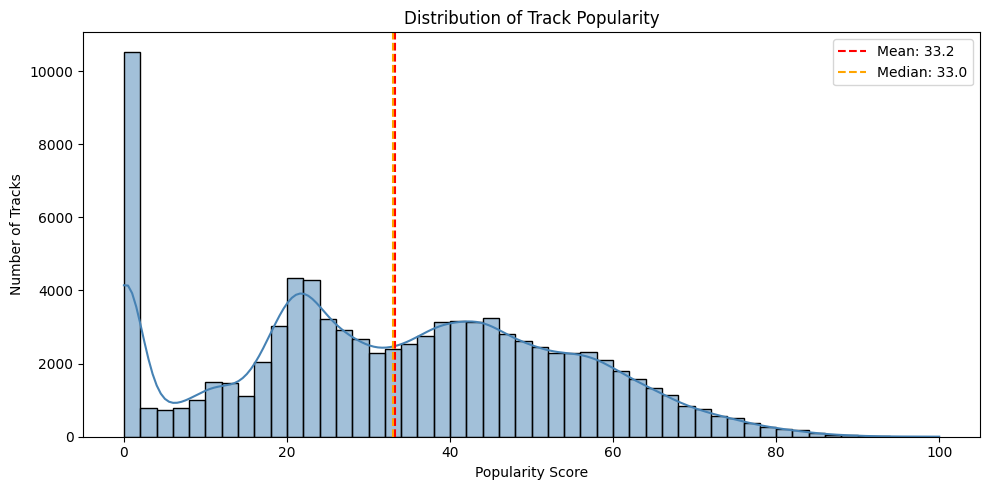

Saved: eda_plot_1.png


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='steelblue')
plt.axvline(df['popularity'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['popularity'].mean():.1f}")
plt.axvline(df['popularity'].median(), color='orange', linestyle='--',
            label=f"Median: {df['popularity'].median():.1f}")
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.legend()
plt.tight_layout()
plt.savefig('eda_plot_1.png')
plt.show()
print("Saved: eda_plot_1.png")

## EDA Operation 4 — Clustered Correlation Heatmap
Shows how 8 audio features correlate with each other. Red = strong positive, Blue = strong negative.

Saved: eda_plot_2.png


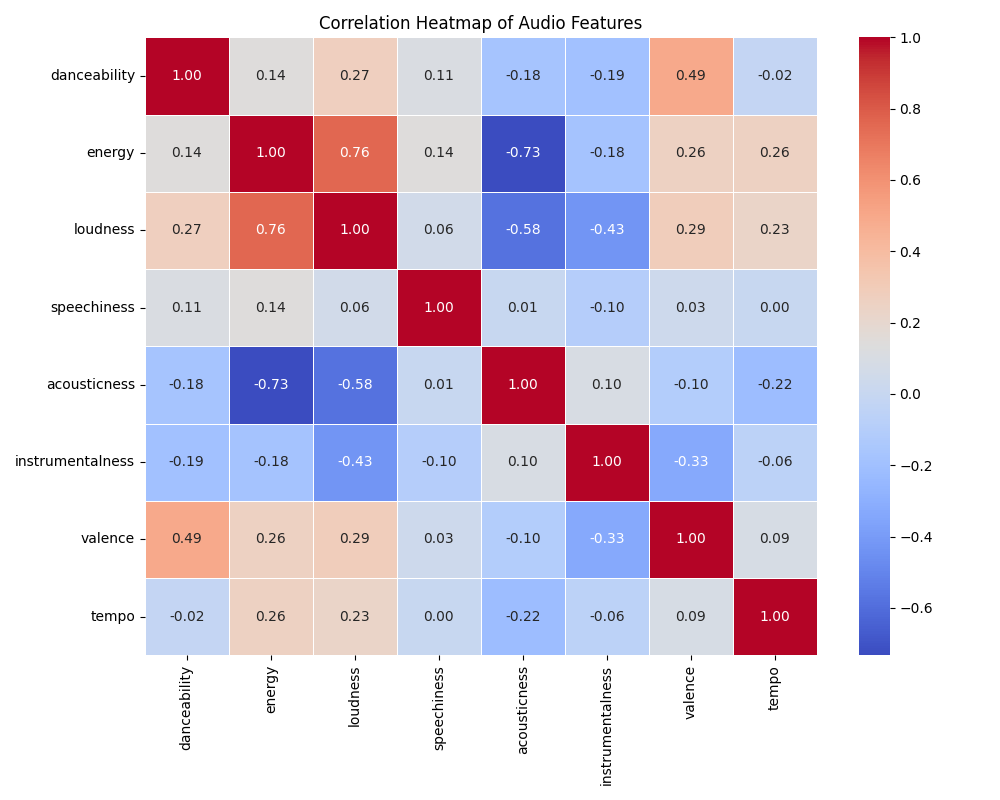

In [13]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'valence', 'tempo']

corr = df[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.savefig('eda_plot_2.png')
plt.close()
print("Saved: eda_plot_2.png")

from IPython.display import Image
Image('eda_plot_2.png')

## EDA Operation 5 — Top 15 Genres by Average Popularity
Horizontal bar chart showing which genres have the highest average popularity score.

Saved: eda_plot_3.png


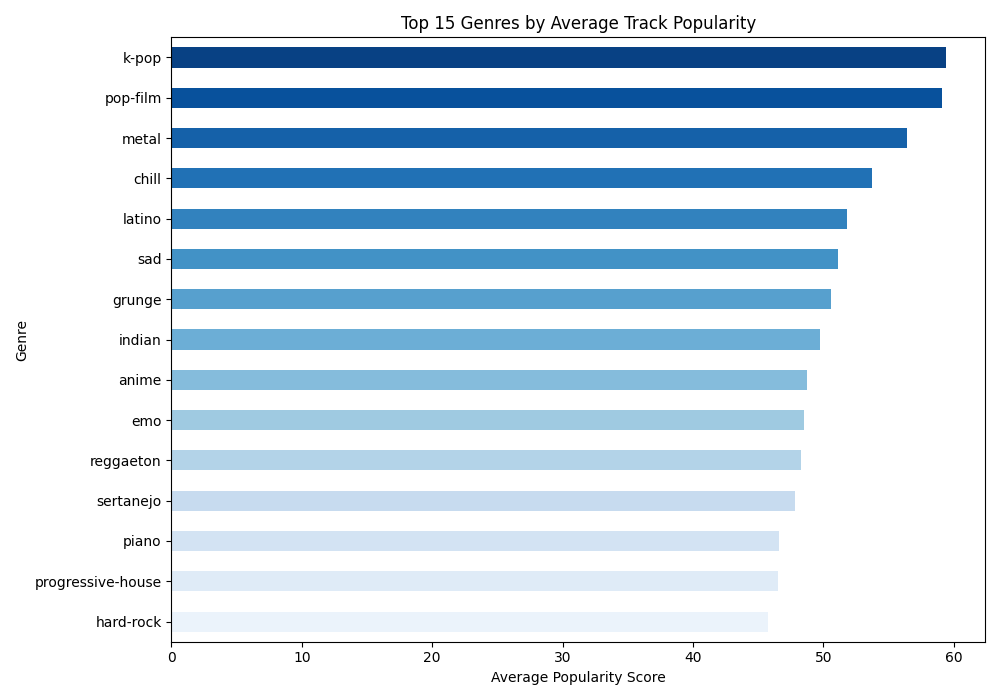

In [15]:
top_genres = (df.groupby('track_genre')['popularity']
              .mean()
              .sort_values(ascending=False)
              .head(15))

plt.figure(figsize=(10, 7))
colors = sns.color_palette("Blues_r", len(top_genres))
top_genres.plot(kind='barh', color=colors)
plt.title('Top 15 Genres by Average Track Popularity')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('eda_plot_3.png')
plt.close()
print("Saved: eda_plot_3.png")

from IPython.display import Image
Image('eda_plot_3.png')

## EDA Operation 6 — Audio Features by Popularity Group
Tracks split into Low/Medium/High popularity groups. 4 boxplots compare audio features across groups.

Saved: eda_plot_4.png


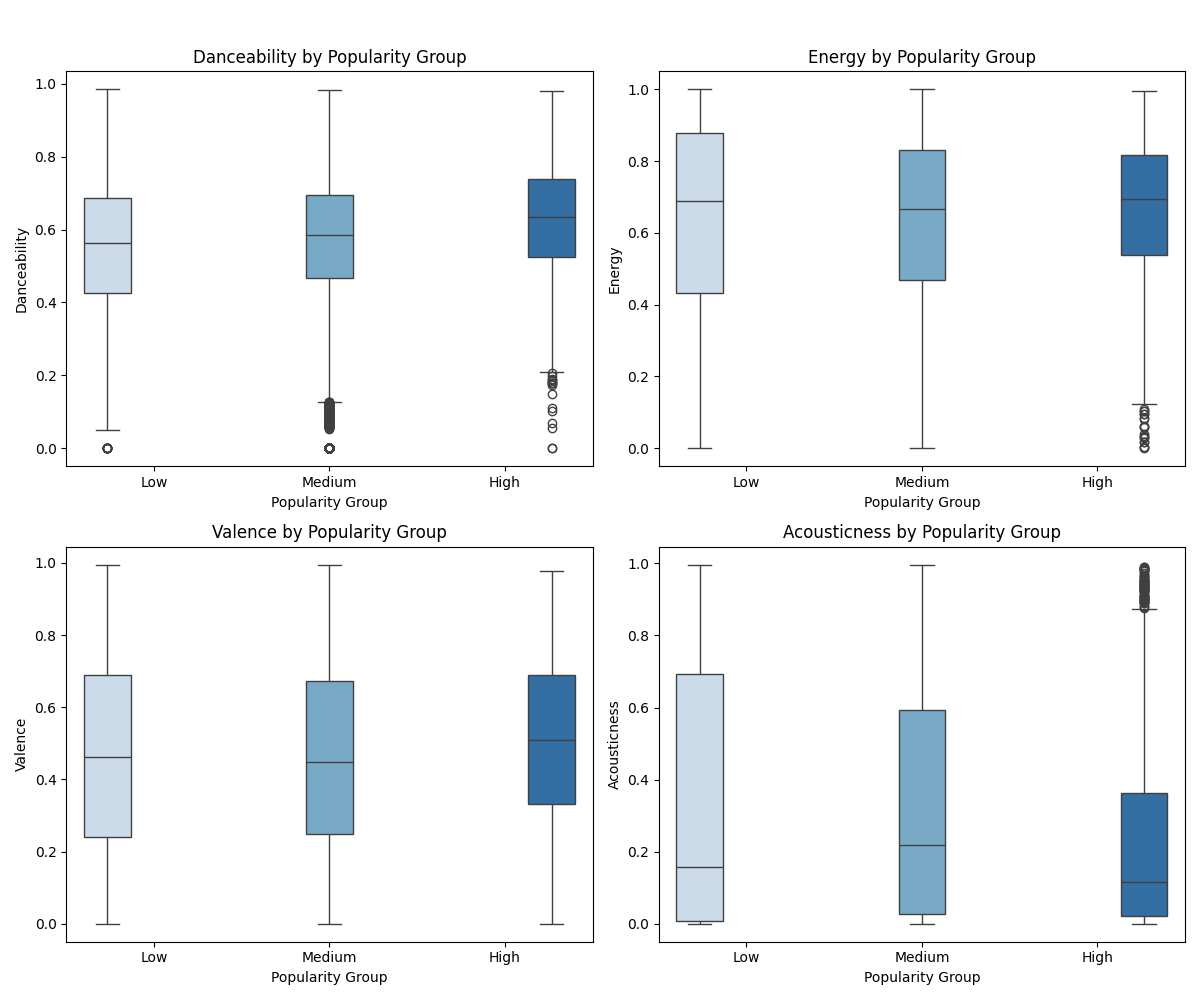

In [17]:
df['popularity_group'] = pd.cut(
    df['popularity'],
    bins=[0, 30, 70, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

features = ['danceability', 'energy', 'valence', 'acousticness']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='popularity_group', y=feature, data=df, ax=axes[i],
                hue='popularity_group', palette='Blues', legend=False, orient='v')
    axes[i].set_title(f'{feature.capitalize()} by Popularity Group')
    axes[i].set_xlabel('Popularity Group')
    axes[i].set_ylabel(feature.capitalize())

plt.suptitle('Audio Feature Distribution by Popularity Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_plot_4.png')
plt.close()
print("Saved: eda_plot_4.png")

from IPython.display import Image
Image('eda_plot_4.png')